Cookie Cats Data Exploration

This script explores the Cookie Cats dataset to understand its structure,
basic statistics, and prepare for A/B testing analysis.

To use this as a Jupyter notebook:
1. Run: jupyter notebook in the notebooks directory
2. Create a new notebook and use %load 01_exploration.py
3. Run the cells

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load the dataset
try:
    data_path = os.path.join('..', 'data', 'cookie_cats.csv')
    df = pd.read_csv(data_path)
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Dataset not found. Please ensure the file 'cookie_cats.csv' is in the data/ directory.")

Dataset loaded successfully!
Shape: (90189, 5)


## 2. Data Overview

Display basic information about the dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [4]:
# Display the first few rows
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [5]:
# Summary statistics for numerical columns
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


## 3. Data Quality Check

Check for missing values

In [6]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64


In [7]:
# Check for duplicate user IDs
print(f"Number of duplicate user IDs: {df['userid'].duplicated().sum()}")

Number of duplicate user IDs: 0


In [8]:
# Check unique values in categorical columns
df['version'].value_counts()

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

## 4. Exploratory Data Analysis

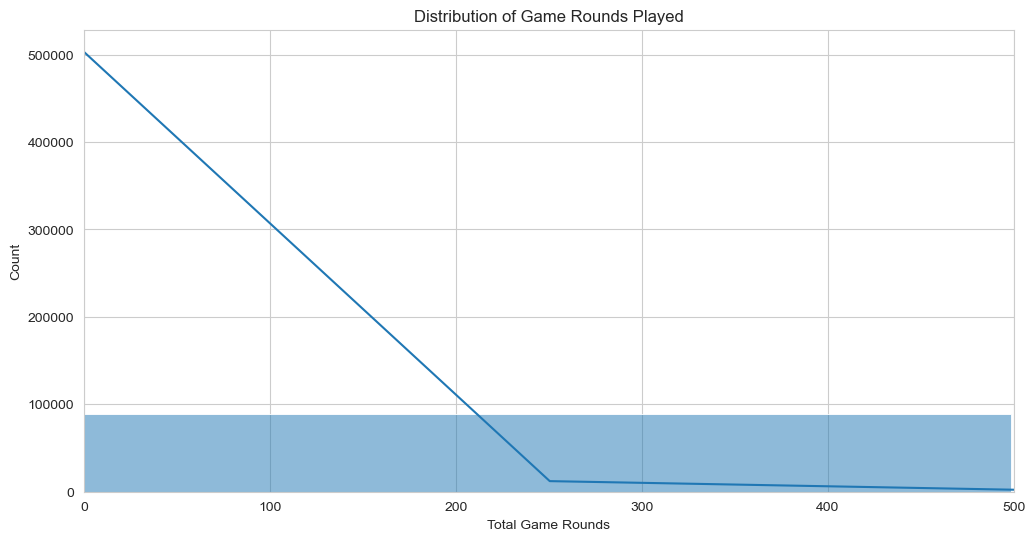

In [9]:
# Distribution of game rounds
plt.figure(figsize=(12, 6))
sns.histplot(df['sum_gamerounds'], bins=100, kde=True)
plt.title('Distribution of Game Rounds Played')
plt.xlabel('Total Game Rounds')
plt.ylabel('Count')
plt.xlim(0, 500)  # Limit x-axis for better visualization
plt.show()

In [10]:
# Retention rates by version
a_b_groups = df.groupby('version')['retention_7'].mean().reset_index()
print("7-day retention rates by group:")
print(a_b_groups)

7-day retention rates by group:
   version  retention_7
0  gate_30     0.190201
1  gate_40     0.182000


C:\Users\seift\AppData\Local\Temp\ipykernel_17552\2922717713.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='version', y='retention_7', data=a_b_groups, ci=95)


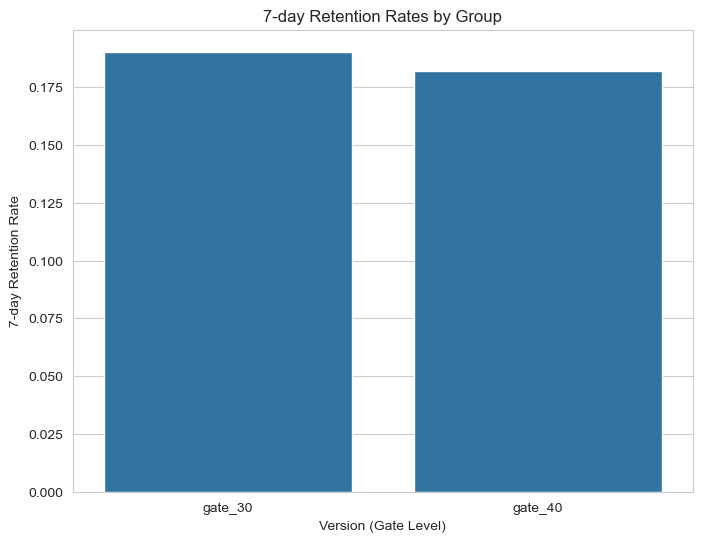

In [11]:
# Visualize retention rates
plt.figure(figsize=(8, 6))
sns.barplot(x='version', y='retention_7', data=a_b_groups, ci=95)
plt.title('7-day Retention Rates by Group')
plt.xlabel('Version (Gate Level)')
plt.ylabel('7-day Retention Rate')
plt.show()

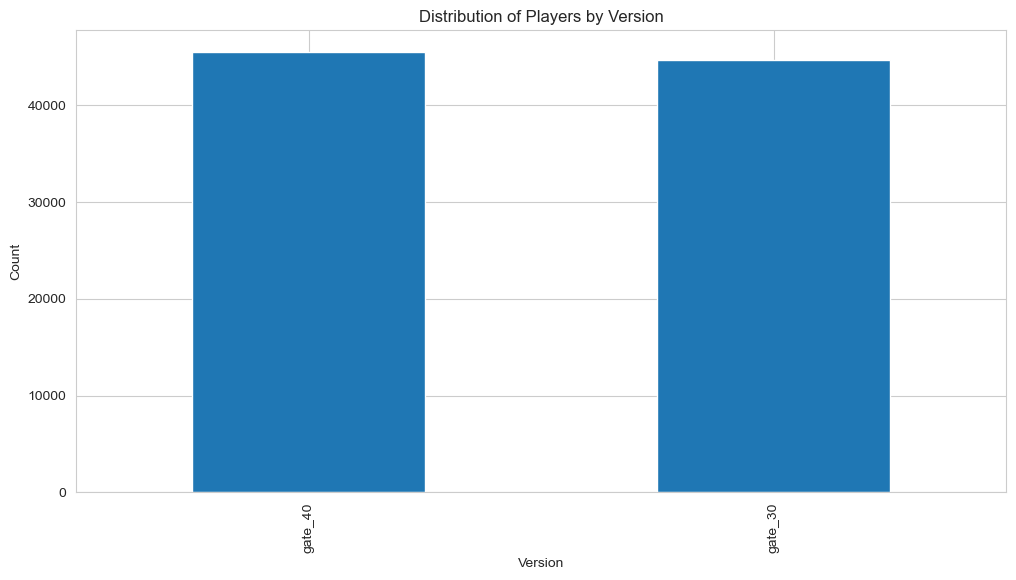

In [12]:
# Distribution of players by version
df['version'].value_counts().plot(kind='bar')
plt.title('Distribution of Players by Version')
plt.xlabel('Version')
plt.ylabel('Count')
plt.show()

## 5. Data Preparation for A/B Testing

In [13]:
# Create separate dataframes for each group
gate_30 = df[df['version'] == 'gate_30']
gate_40 = df[df['version'] == 'gate_40']

print(f"Gate 30 group size: {len(gate_30)}")
print(f"Gate 40 group size: {len(gate_40)}")

Gate 30 group size: 44700
Gate 40 group size: 45489


In [14]:
# Check retention rates
retention_30 = gate_30['retention_7'].mean()
retention_40 = gate_40['retention_7'].mean()

print(f"7-day retention for gate_30: {retention_30:.4f}")
print(f"7-day retention for gate_40: {retention_40:.4f}")
print(f"Difference: {retention_40 - retention_30:.4f}")

7-day retention for gate_30: 0.1902
7-day retention for gate_40: 0.1820
Difference: -0.0082


## 6. Next Steps

In [15]:
print("""This exploration reveals:
1. The dataset structure and key variables
2. Initial retention rate differences between groups
3. Data quality and distribution characteristics

Next steps:
- Perform bootstrap analysis to assess statistical significance
- Create visualizations of the A/B test results
- Build machine learning models to predict retention""")

This exploration reveals:
1. The dataset structure and key variables
2. Initial retention rate differences between groups
3. Data quality and distribution characteristics

Next steps:
- Perform bootstrap analysis to assess statistical significance
- Create visualizations of the A/B test results
- Build machine learning models to predict retention
